<a href="https://colab.research.google.com/github/Harsh-Prajapati54/NLP----/blob/main/Text_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Text Classification



In this notebook we are going too build an emotion detector of an human from the text they have written , we are going to classify ` anger, disgust, fear, joy, sadness, and surprise.` emotions of the humans

***our task will be to train a model that can classify it into one of these emotions.***

#### Installing compatible versions

In [1]:
!pip install -q \
  "transformers==4.40.0" \
  "datasets==2.19.0" \
  "huggingface_hub==0.23.0" \
  "accelerate==0.29.0" \
  "scikit-learn" \
  "umap-learn" \
  "nltk"

In [2]:
from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")  # add token in Colab secrets 🔑

### Download Datasets
from HuggingFace

In [3]:
from datasets import load_dataset

emotions = load_dataset("emotion")
print(emotions)

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [4]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
train_ds = emotions["train"]
train_ds

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [6]:
len(train_ds)

16000

In [8]:
train_ds[0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [9]:
train_ds.column_names

['text', 'label']

In [10]:
print(train_ds.features)

{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


Now lets convert this dictoniory based dataset into rows and column (tabular)

In [11]:
import pandas as pd
emotions.set_format("pandas")
df = emotions["train"][:]

In [12]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [13]:
def label_int2str(row):
    return emotions["train"].features["label"].int2str(row)

df["label_name"] = df["label"].apply(label_int2str)
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


hence it is an classification problem lets check the distribution of data hence balanced and skwed dataset requires diffrent treatments for best result in model training

Text(0.5, 1.0, 'distribution of class')

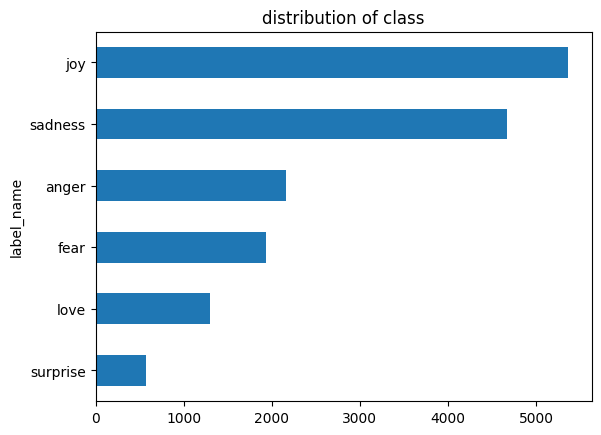

In [14]:
import matplotlib.pyplot as plt

df["label_name"].value_counts(ascending=True).plot.barh()
plt.title("distribution of class")